In [1]:
from pynq import Overlay, allocate
import numpy as np

print("Loading overlay...")
o = Overlay("cfd_04.xsa")
print("Done")

Loading overlay...


Done


In [2]:
CFD_THRESHOLD = 50 * 8
CFD_ZERO = 0
o.cfd_params.channel1.write(CFD_THRESHOLD, 0x1FFFF) # Masking to 17 bits
o.cfd_params.channel2.write(CFD_ZERO, 0x1FFFF)

print("=== Read back ===")
print("CFD_THRESHOLD", o.cfd_params.channel1.read())
print("CFD_ZERO", o.cfd_params.channel2.read())

=== Read back ===
CFD_THRESHOLD 400
CFD_ZERO 0


In [3]:
def pack_data_for_dma(filename='input.csv'):
    """
    Reads u16 samples from a CSV file, truncates them to 12 bits,
    packs them into 192 bits, and pads with zeros to fill 256-bit 
    (8x 32-bit words) AXI Stream beats.
    """
    # Read integers from the file, assuming one per line
    u16_array = np.loadtxt(filename, dtype=np.uint16)
    u16_array = u16_array[16:].copy() # WORKAROUND: simulation loses the first packet
    
    # Ensure data is a multiple of 16 samples
    remainder = len(u16_array) % 16
    if remainder != 0:
        # Pad with zeros to make it a multiple of 16
        u16_array = np.append(u16_array, np.zeros(16 - remainder, dtype=np.uint16))

    num_beats = len(u16_array) // 16

    # Allocate DMA buffer: Shape is (num_beats, 8) of 32-bit integers.
    # 8 * 32 bits = 256 bits per beat
    dma_buffer = allocate(shape=(num_beats, 8), dtype=np.uint32)

    print(f"Packing {len(u16_array)} samples from {filename} into {num_beats} AXI-Stream beats...")
    for i in range(num_beats):
        chunk = u16_array[i*16 : (i+1)*16]
        packed_192bit = 0

        # Pack 16 samples into a 192-bit Python integer
        for j, sample in enumerate(chunk):
            # Mask to 12 bits and shift to the correct position
            sample_12b = int(sample) & 0xFFF
            packed_192bit |= (sample_12b << (j * 12))

        # Slice the 192-bit integer into six 32-bit words
        for w in range(6):
            dma_buffer[i, w] = (packed_192bit >> (w * 32)) & 0xFFFFFFFF

        # The last 2 words (64 bits) remain 0 to fulfill the 256-bit width
        dma_buffer[i, 6] = 0
        dma_buffer[i, 7] = 0

    return u16_array, dma_buffer

In [4]:
data_arr, dma_data = pack_data_for_dma()
dma_data.flush()

Packing 784 samples from input.csv into 49 AXI-Stream beats...


In [5]:
o.dma.sendchannel.stop()
o.dma.sendchannel.start()

print("Starting DMA transfer...")
o.dma.sendchannel.transfer(dma_data)
o.dma.sendchannel.wait()
print("Done")

Starting DMA transfer...
Done


In [6]:
fifo_load = o.out_fifo.read(0x1C) & 0x7FFFFFFF
print("Timestamp count: ", fifo_load)

timestamps = np.zeros(fifo_load)
for i in range(fifo_load):
    data = o.out_fifo.read(32)
    timestamps[i] = data
print(timestamps)

Timestamp count:  10
[ 43. 103. 162. 222. 283. 383. 463. 494. 576. 642.]


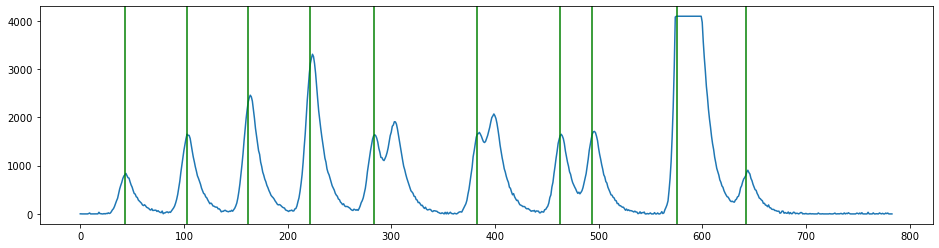

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.plot(data_arr)
for ts in timestamps:
    plt.axvline(x=ts, color='g')
plt.show()

In [8]:
sim_timestamps = [43, 103, 162, 222, 283, 383, 463, 494, 576, 642]
print(timestamps - sim_timestamps)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
